## Inference for a Gaussian model  

Family name: Yu

Name: Belisa

Date: 22/02/2026

#### Important
In the code include the appropriate docstrings (Google style) and minimal complete doctests.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Maximum likelihood (ML) and Maximum posterior (MAP) [programming + numerical illustration]

1. Code in a separate file called `gaussian_distribution.py` in the `tools` folder, without using `scipy` a vectorized function called `gaussian_pdf` to compute the probability density function (pdf) of a 1-dimensional Gaussian.
    1. Generate a sample of size $N = 10^6$ from a normal distribution with mean $\mu = 5.0$, $\sigma = 1.0$
    2. Fit a Gaussian to these data using maximum likelihood (ML).
    3. Assume a Gaussian prior for $\mu$ centered at $0.0$ with a standard deviation $3.0$
    4. **Illustrate with an animation** how the Gaussian distribution whose standard deviation is given by the ML estimate, and whose mean is the value that maximizes the posterior of $\mu$, evolves as more data instances are considered in the computation of the posterior.



**ML of a gaussian distribution:** <br>
$$\text PDF: f(x|\mu,\sigma) = \frac{1}{\sqrt{2\pi\sigma^{2}}}exp(-\frac{(x-\mu)^{2}}{2\sigma^{2}})
$$

- Maximum Likelihood:
    - $L(\lambda; x_{1},...,x_{n}) = \prod_{n=1}^{N}f(x_{n};\lambda)$
- Log-Likelihood:
    - $LL(\lambda) = log L(\lambda) = \sum_{n=1}^{N}log f(x_{n};\lambda) = -\frac{N}{2}log(2\pi\sigma^{2})-\frac{1}{2\sigma^{2}}\sum_{i=1}^{N}(x_{i}-\mu)^{2}$

- Derive respect $\mu$ and $\sigma$:
    - $\mu^{*} = \frac{1}{N}\sum_{i=1}^{N} x_{i}$
    - $\sigma^{*} = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(x_{i}-\mu^{*})^{2}}$


**MAP of a gaussian distribution:**
$$\mu_{MAP} = argmax_{\mu} p(\mu|x)
$$

- Bayes: $p(\mu,\sigma|x) ∝ p(x|\mu,\sigma) +  log\ p(\mu)$
- $log\ p(\mu,\sigma|x) = log\ p(x|\mu,\sigma)+log\ p(\mu)$
- Log-likelihood:
    - $log\ (x|\mu,\sigma) = -\frac{N}{2}log(2\pi) - Nlog\  \sigma-\frac{1}{2\sigma^{2}}\sum_{i=1}^{N}(x_{i}-\mu)^{2}$
- Log-prior:
    - $log\ p(\mu) = -\frac{1}{2\sigma^{2}}(\mu - \mu_{0})^{2}$
- Log-posterior:
    - $L(\mu, \sigma) = -Nlog\ \sigma - \frac{1}{2\sigma^{2}}\sum(x_{i}-\mu)^{2} - \frac{1}{2\sigma_{0}^{2}}(\mu-\mu_{0})^{2}$

- Derive respect $\mu$ and $\sigma$
    - $\mu_{MAP} = \frac{\frac{N}{\sigma^{2}}x^{'}+\frac{1}{\sigma_{0}^{2}}\mu_{0}}{\frac{N}{\sigma_{0}^{2}}+ \frac{1}{\sigma_{0}^{2}}}$
    
    - $\sigma_{MAP} = \sqrt{\frac{1}{N}\sum(x_{i}-\mu_{MAP})^{2}}$

In [2]:
from tools.gaussian_distribution import gaussian_pdf

In [3]:
N = 10**6
sample = np.random.normal(loc=5.0, scale=1.0, size = N)

#Maximum likelihood
mu_ml = (1/N)*np.sum(sample)
std_ml = np.sqrt((1/N)*np.sum((sample-mu_ml)**2))

#Maximum Posteriori
##Prior data:
mu_prior = 0.0
std_prior = 3.0
mu_map = ((N/std_ml**2)*mu_ml+(1/std_prior**2)*mu_prior)/((N/std_ml**2)+(1/std_prior**2))
std_map = np.sqrt((1/N)*np.sum((sample-mu_map)**2))

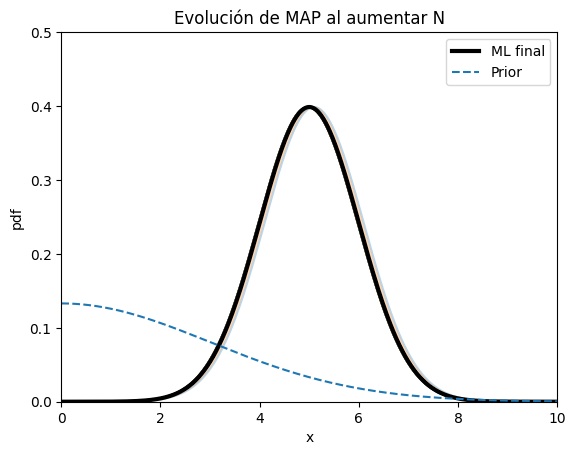

In [4]:
plt.figure()
plt.xlim(0,10)
plt.ylim(0,0.05)
x_vals = np.linspace(0,10,500)
for i in range(10,N,500):
    subset = sample[:i]
    x_bar = np.mean(subset)

    mu_map = ((N/std_ml**2)*x_bar+(1/std_prior**2)*mu_prior)/((N/std_ml**2)+(1/std_prior**2))

    y = gaussian_pdf(x_vals, mu_map, std_ml)

    plt.plot(x_vals,y,alpha=0.3)

mu_final = np.mean(sample)
y_ml = gaussian_pdf(x_vals, mu_ml, std_ml)
plt.plot(x_vals, y_ml, color="black", linewidth=3, label="ML final")

y_prior = gaussian_pdf(x_vals, mu_prior, std_prior)
plt.plot(x_vals, y_prior, linestyle="--", label="Prior")
plt.title("Evolución de MAP al aumentar N")
plt.xlim(0,10)
plt.ylim(0,0.5)
plt.xlabel("x")
plt.ylabel("pdf")
plt.legend()
plt.show();


### Multivariate Gaussian [programming + numerical illustration]
2. Code in a separate file called `gaussian_distribution.py` in the `tools` folder, without using `scipy` a a vectorized function called called `multivariate_gaussian_pdf` to compute the probability density function (pdf) of a D-dimensional Gaussian.
3. For a 2D Gaussian
    1. Create a **3D plot** of the pdf of a single 2D Gaussian with $\boldsymbol{\mu} = \begin{pmatrix} 3.0 \\ -5.0 \end{pmatrix}$, $\boldsymbol{\Sigma} = \begin{pmatrix} 1.7 & -0.8 \\ -0.8 & 0.9 \end{pmatrix}$
    3. Generate a **sample** from this distribution of size $N = 1000$.
    4. Create a **2D scatter plot** to visualize the sample.
    5. Overlay the **equiprobability ellipses** (contour lines).
    6. On the ellipse, draw the **eigenvectors** of the covariance matrix with lengths proportional to the square root of the **eigenvalues**, verifying that they correspond to the major and minor axes
    7. Use numerical optimimaximum likelihood (ML) to estimate the mean and the variance of this Gaussian.


In [5]:
from tools.gaussian_distribution import multivariate_gaussian_pdf

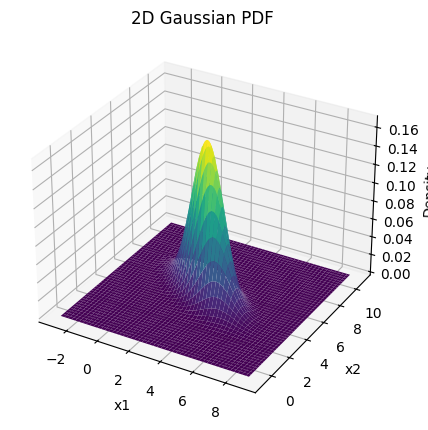

In [6]:
mu = np.array([3.0,5.0])
cov = np.array([[1.7,-0.8],[-0.8,0.9]])

## We use eigenvalues to estimate the extension of the distribution
eigenvalues, _ = np.linalg.eigh(cov)

std_max = np.sqrt(np.max(eigenvalues))

x = np.linspace(mu[0] - 4*std_max, mu[0] + 4*std_max, 200)
y = np.linspace(mu[1] - 4*std_max, mu[1] + 4*std_max, 200)

X,Y = np.meshgrid(x,y)
pos = np.column_stack([X.ravel(),Y.ravel()]) #convert the grid to (N,2)
Z = multivariate_gaussian_pdf(pos, mu, cov)
Z = Z.reshape(X.shape)
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')

ax.set_title("2D Gaussian PDF")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("Density")

plt.show();

**CHOLESKY**
z ~ N(0,I) if we apply a lineal transformation: x = Az + $\mu$, leading to:
- Mean: E[x] = AE[z] + $\mu = \mu$
- Cov: Cov(x) = $E[(x-\mu)(x-\mu)^{T}] = E[Azz^{T}A^{T}] = AE[zz^{T}]A^{T}$; Cov(z) = I => $E[zz^{T}] = I$; Cov(x) = $AA^{T}$

If A = L, we get: x = $\mu$ + Lz --> Cov(x) = $LL^{T} = \sum$

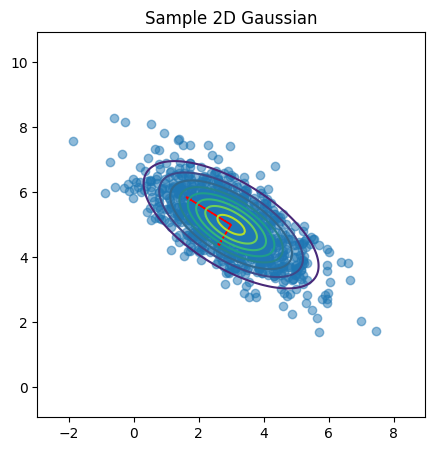

In [7]:
# To create the sample we will use Cholesky, LL^T = COV
N = 1000
L = np.linalg.cholesky(cov)
Z_sample = np.random.randn(N,2)
x_sample = mu+Z_sample@L.T
eigenvalues, eigenvectors = np.linalg.eigh(cov)

plt.figure(figsize=(5,5))
plt.scatter(x_sample[:,0], x_sample[:,1], alpha = 0.5)
plt.contour(X,Y,Z, levels=10)
# Draw eigenvectors
for i in range(2):
    vec = eigenvectors[:,i]
    length = np.sqrt(eigenvalues[i])
    plt.arrow(mu[0],mu[1],length*vec[0], length*vec[1], head_width = 0.1, linewidth=1, color='red')
plt.axis('equal')
plt.title('Sample 2D Gaussian')
plt.show()

**ML of multivariate distribution**
- Multivariate distribution: <br>
$$p(x|\mu,\Sigma) =\frac{1}{(2\pi)^{D/2}|\Sigma|^{1/2}}exp(-\frac{1}{2}(x_{n}-\mu)^{T}\Sigma^{-1}(x_{n}-\mu))
$$

- Log-likelihood
    - $L(\mu,\Sigma) = \prod_{n=1}^{N}p(x_{n}|\mu,\Sigma)$
    - $log\ L(\mu,\Sigma) = -\frac{ND}{2}log(2\pi)-\frac{N}{2}log|\Sigma| - \frac{1}{2}\sum_{n=1}^{N}(x_{n}-\mu)^{T}\Sigma^{-1}(x_{n}-\mu)$

- Deriving $\mu$ and $\Sigma$
    - $\mu_{ML} = \frac{1}{N}\sum_{n=1}^{N}x_{n}$
    - $\Sigma_{ML} = \frac{1}{N}\sum_{n=1}^{N}(x_{n}-\mu_{ML})(x_{n}-\mu_{ML})^{T}$

In [8]:
N = x_sample.shape[0]
mu_ML = np.mean(x_sample,axis=0)
Sigma_ML = (x_sample-mu_ML).T @ (x_sample-mu_ML)/N 
print('ML estimate of mean:', mu_ML)
print('ML estimate of Sigma:', Sigma_ML)

ML estimate of mean: [2.93806364 5.03426506]
ML estimate of Sigma: [[ 1.60121325 -0.8069422 ]
 [-0.8069422   0.91775558]]


### MAP for a multivariate Gaussian [markdown derivation + programming + numerical illustration]
4. Consider the data $ \mathcal{D} = \left\{ \mathbf{x}_n \right\}_{n=1}^N $, which is assumed to be an iid sample from a D-dimensional multivariate Gaussian distribution with unknown $\boldsymbol{\mu}$, and known $\boldsymbol{\Sigma}$
Assuming the prior for $ p(\boldsymbol{\mu}) = \mathcal{N}\left(\boldsymbol{\mu}_0, M^{-1} \Sigma  \right) $ 
    1. Derive the posterior distribution  $p(\boldsymbol{\mu} \vert \mathcal{D})$.
    2. Derive $\boldsymbol{\mu}^*_{\text{prior}}$, the value of $\boldsymbol{\mu}$ that maximizes the prior.
    3. Derive $\boldsymbol{\mu}^*_{ML}$, the value of $\boldsymbol{\mu}$ that maximizes the likelihood.
    4. Derive $\boldsymbol{\mu}^*_{MAP}$, the value of $\boldsymbol{\mu}$ that maximizes the posterior.
    5. Illustrate with the data from the previous exercise with $\boldsymbol{\mu} = \begin{pmatrix} 2.0 \\ -4.0 \end{pmatrix}$ how the value $\boldsymbol{\mu}^*_{MAP}$ evolves as a function of $N$ and $M$. 
    6. From these results, provide an interpretation of $M$ in the prior? 
    

**1. Derive $p(\mu|D)$**
- $p(D|\mu) = \prod_{n=1}^{N}\frac{1}{(2\pi)^{D/2}|\Sigma|^{1/2}}exp(-\frac{1}{2}(x_{n}-\mu)^{T}\Sigma^{-1}(x_{n}-\mu))$
- prior: $p(\mu|D) = exp(-\frac{1}{2}(\mu-\mu_{0})^{T}(M\Sigma^{-1})(\mu-\mu_{0}))$
- posterior: $p(\mu|D) ∝ p(D|\mu)p(\mu)$
- log-posterior: $-\frac{1}{2}\sum_{n=1}^{N}(x_{n}-\mu)^{T}\Sigma^{-1}(x_{n}-\mu)-\frac{1}{2}(\mu-\mu_{0})^{T}(M\Sigma^{-1})(\mu-\mu_{0})+ const$

**2. Prior $\mu_{prior}^{*}$**
- $p(\mu) ∝ exp(-\frac{M}{2}(\mu-\mu_{0})^{T}\Sigma^{-1}(\mu-\mu_{0}))$
- maximum of prior is the value that minimizes $(\mu-\mu_{0})^{T}\Sigma^{-1}(\mu-\mu_{0})$ which is $\mu_{0}$
- So: $\mu_{prior}^{*} = \mu_{0}$

**3. Likelihood $\mu_{ML}^{*}$**
- $\mu_{ML} = \frac{1}{N}\sum_{n=1}^{N}x_{n}$

**4. Posterior $\mu_{MAP}^{*}$**
- $\frac{d}{d\mu}[-\frac{1}{2}\sum_{n=1}^{N}(x_{n}-\mu)^{T}\Sigma^{-1}(x_{n}-\mu)-\frac{1}{2}(\mu-\mu_{0})^{T}(M\Sigma^{-1})(\mu-\mu_{0})] = 0$
- $\sum_{n=1}^{N}(x_{n}-\mu)+ M(\mu_{0}-\mu) = 0\;\ \sum_{n=1}^{N}(x_{n}-\mu)+M(\mu_{0}-\mu) = 0\ ;\ \sum_{n=1}^{N} x_{n} - N\mu + M\mu_{0}- M\mu = 0\;\ (N+M)\mu = \sum_{n=1}^{N}x_{n}+ M\mu_{0}$
- $\mu_{MAP}^{*} = \frac{N\mu_{ML} + M\mu_{0}}{N + M}$

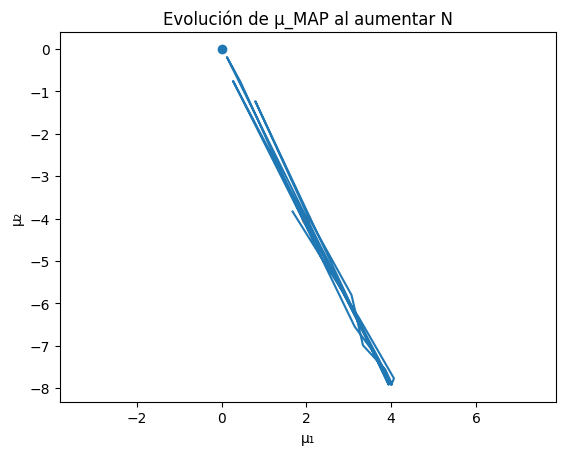

In [9]:
mu = np.array([2.0,-4.0])
mu0 = np.array([0.0,0.0])
N = [1,5,10,50,100,500]
M = [1,5,10,50]

mu_map_list = []
np.random.seed(42)
for m in M:
    for n in N:
        x = mu + np.random.multivariate_normal(mu, Sigma_ML, size=n)
        mu_ml = x.mean(axis=0)
        mu_map = (n*mu_ml +  m*mu0) / (n+m)
        mu_map_list.append(mu_map)

mu_map = np.array(mu_map_list)

plt.figure()
plt.plot(mu_map[:, 0], mu_map[:, 1])
plt.scatter(mu0[0], mu0[1])
plt.scatter(mu[0], mu[1])

plt.xlabel("μ₁")
plt.ylabel("μ₂")
plt.title("Evolución de μ_MAP al aumentar N")
plt.axis("equal")
plt.show()

### The Iris dataset [numerical illustration]
4. Load the Iris dataset.
    1. Select the attributes corresponding to "sepal length" and "petal length".
    2. Center and scale the data using the `StandardScaler` of `scikit-learn`. 
    3. Using ML, fit a 2D Gaussian to the data.
    3. Visualize the fit.
    

In [10]:
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy.stats import multivariate_normal

In [11]:
# Load data
iris = load_iris()
df = pd.DataFrame(iris.data, columns= iris.feature_names)
atributes = df[['sepal length (cm)','petal length (cm)']]

In [12]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(atributes)
mu = np.mean(data_scaled, axis=0)
cov = np.cov(data_scaled.T, bias=True)
samples = multivariate_normal(mu,cov)

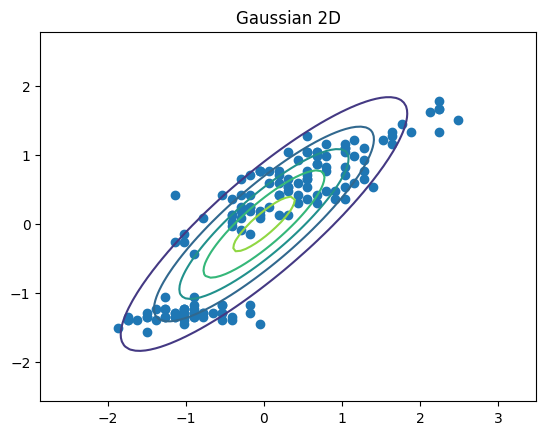

In [13]:
x = np.linspace(data_scaled[:,0].min()-1, data_scaled[:,0].max()+1, 100)
y = np.linspace(data_scaled[:,1].min()-1, data_scaled[:,1].max()+1, 100)

X_grid, Y_grid = np.meshgrid(x, y)
pos = np.dstack((X_grid, Y_grid))

Z = samples.pdf(pos)
plt.scatter(data_scaled[:,0], data_scaled[:,1])
plt.contour(X_grid, Y_grid, Z, levels = 5)
plt.title('Gaussian 2D')
plt.show()